<a href="https://colab.research.google.com/github/RidSis15/IT480-FA26/blob/main/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Ridley Sisson*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:05<00:00, 80.5MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['non_fire_images', 'fire_images'] (0 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)


In [6]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

In [7]:
# Your exploration here

def count_images_per_class(dataset, class_names):
    class_counts = {class_name: 0 for class_name in class_names}
    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[class_names[label]] += 1
    return class_counts

print("\n--- Fire Dataset Class Counts ---")

# Training Set
train_counts = count_images_per_class(train_raw_fire, class_names_fire)
print("Training set class counts:", train_counts)

# Validation Set
val_counts = count_images_per_class(val_raw_fire, class_names_fire)
print("Validation set class counts:", val_counts)

# Test Set
test_counts = count_images_per_class(test_raw_fire, class_names_fire)
print("Test set class counts:", test_counts)


--- Fire Dataset Class Counts ---
Training set class counts: {'fire_images': 538, 'non_fire_images': 162}
Validation set class counts: {'fire_images': 96, 'non_fire_images': 43}
Test set class counts: {'fire_images': 117, 'non_fire_images': 43}


*What did you notice about this dataset? Does it change how you'll approach the next steps?*


In the training set there are 538 images with fire in them and only 162 images that do not involve fire in them. This difference of 376 images may make the model biased to fire detection in images as the quanities are very swayed towards fire_images. So with this understanding I will likely assign higher weights to the minority class forcing the model to represent the non-fire images better.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [10]:
# Preprocess the data here
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds_fire = train_raw_fire.map(preprocess).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_fire = val_raw_fire.map(preprocess).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_fire = test_raw_fire.map(preprocess).prefetch(buffer_size=tf.data.AUTOTUNE)


In [11]:
# Calculate class weights to handle imbalance
# Image counts
fire_count = train_counts['fire_images']
non_fire_count = train_counts['non_fire_images']

total_samples = fire_count + non_fire_count

# Class Weights Calculation
weight_for_0 = (1 / fire_count) * (total_samples / 2.0)
weight_for_1 = (1 / non_fire_count) * (total_samples / 2.0)

class_weights = {
    class_names_fire.index('fire_images'): weight_for_0,
    class_names_fire.index('non_fire_images'): weight_for_1
}

print("Calculated Class Weights:", class_weights)
print(f"For class '{class_names_fire[0]}' (fire_images): {weight_for_0:.2f}")
print(f"For class '{class_names_fire[1]}' (non_fire_images): {weight_for_1:.2f}")

Calculated Class Weights: {0: 0.6505576208178439, 1: 2.1604938271604937}
For class 'fire_images' (fire_images): 0.65
For class 'non_fire_images' (non_fire_images): 2.16


In [13]:
# Build your model here

base_model_mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_mobilenet.trainable = False  # Freeze the base

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
#x = Dropout(0.3)(x)
output = Dense(len(class_names_fire), activation='softmax')(x)

mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)

In [14]:
# Compile your model here

mobilenet_model.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [15]:
# Train Model here (Used the validation split created above)
mobilenet_history = mobilenet_model.fit(
    train_ds_fire,
    validation_data=val_ds_fire,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.8786 - loss: 0.2884 - val_accuracy: 0.9640 - val_loss: 0.1287
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9714 - loss: 0.0990 - val_accuracy: 0.9856 - val_loss: 0.0607
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9814 - loss: 0.0754 - val_accuracy: 0.9928 - val_loss: 0.0486
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9829 - loss: 0.0582 - val_accuracy: 0.9712 - val_loss: 0.0631
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9900 - loss: 0.0497 - val_accuracy: 0.9784 - val_loss: 0.0609


In [18]:
# Report validation and test accuracy here
# Validation Set
val_loss, val_accuracy = mobilenet_model.evaluate(val_ds_fire)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Test Set
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds_fire)
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 985ms/step - accuracy: 0.9568 - loss: 0.0867
Validation Accuracy: 0.9568
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9812 - loss: 0.0579
Test Accuracy: 0.9812


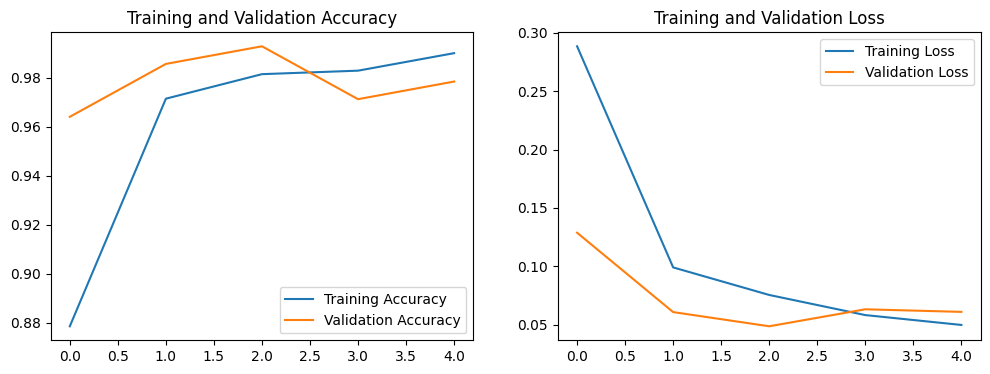

In [20]:
# Training and validation Accuracy and Loss shown visually

acc = mobilenet_history.history['accuracy']
val_acc = mobilenet_history.history['val_accuracy']

loss = mobilenet_history.history['loss']
val_loss = mobilenet_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step


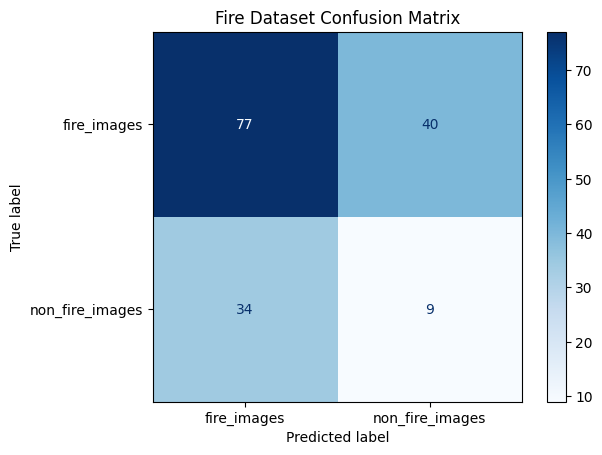

In [22]:
# True labels from the test dataset
true_labels = np.concatenate([y.numpy() for x, y in test_ds_fire], axis=0)

# Get model predictions on the test dataset
predictions = mobilenet_model.predict(test_ds_fire)
predicted_labels = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=range(len(class_names_fire)))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap=plt.cm.Blues)
plt.title('Fire Dataset Confusion Matrix')
plt.show()

*Your answer:*
A false negative would likely be more costly as missing a real fire would likely be catastrophic without warning and a false alarm is safer than no alarm in a real danger situation. To make the model even safer, lowering the decision threshold would push the model to be more sensitive to detecting fire with a small increase in false alarms, prioritizing the safety of the people in this situation.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [23]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Residential', 'HerbaceousVegetation', 'AnnualCrop', 'Industrial', 'Forest', 'Highway', 'Pasture', 'River', 'SeaLake']


In [24]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
# Preprocess the data here



In [ ]:
# Build your model here



In [ ]:
# Compile your model here



## 2C — Train and Evaluate

In [ ]:
# Train your model here



In [ ]:
# Report validation and test accuracy here



## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here



*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | | |
| Test Accuracy | | |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.